In [1]:
import pandas as pd
dataset = pd.read_csv("Social_Network_Ads.csv")

In [2]:
dataset.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [3]:
dataset = dataset.drop(columns=(['User ID']))

In [4]:
dataset.head(2)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0


In [5]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [6]:
dataset.head(2)

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1


In [7]:
dataset.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [8]:
independent=dataset[['Age', 'EstimatedSalary','Gender_Male']]
dependent=dataset[['Purchased']]

In [9]:
dependent.value_counts()

Purchased
0            257
1            143
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(independent, dependent, test_size=1/3, random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [12]:
X_train=sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
from sklearn.svm import SVC

In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
param_grid = {'kernel':['linear', 'rbf', 'sigmoid'],
              'gamma':['scale', 'auto'], 'C':[10,100,1000,2000,3000]}

In [17]:
grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=3, n_jobs=-1, scoring='f1_weighted')

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,SVC(probability=True)
,param_grid,"{'C': [10, 100, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [20]:
re=grid.cv_results_

In [21]:
grid_pred = grid.predict(X_test)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

In [23]:
cm=confusion_matrix(y_test, grid_pred)
print(cm)

[[80  5]
 [ 7 42]]


In [24]:
clf=classification_report(y_test,grid_pred)
print(clf)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        85
           1       0.89      0.86      0.88        49

    accuracy                           0.91       134
   macro avg       0.91      0.90      0.90       134
weighted avg       0.91      0.91      0.91       134



In [25]:
print("The best grid parameter is {}".format(grid.best_params_))

The best grid parameter is {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [26]:
from sklearn.metrics import f1_score
f1_macro = f1_score(y_test,grid_pred,average='weighted')
print("The F1 value for the best grid parameter is {}".format(grid.best_params_), f1_macro)

The F1 value for the best grid parameter is {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'} 0.9100355779243318


In [27]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, grid.predict_proba(X_test)[:,1])

0.9539015606242497

In [28]:
import matplotlib.pyplot as plt
from sklearn import metrics

In [29]:
y_pred_proba= grid.predict_proba(X_test)[:,1]

In [30]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

In [31]:
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

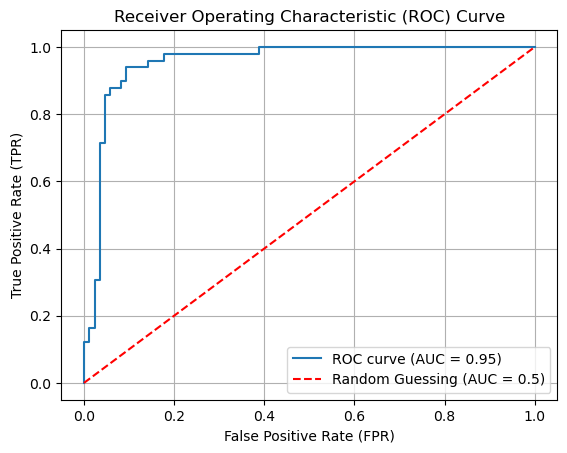

In [32]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing (AUC = 0.5)') # Diagonal baseline
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [33]:
table = pd.DataFrame.from_dict(re)

In [34]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.038662,0.008267,0.031279,0.005940,10,scale,linear,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,11
1,0.042364,0.004669,0.027077,0.002205,10,scale,rbf,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.867478,0.886792,0.869709,0.944161,0.943041,0.902236,0.034431,3
2,0.026292,0.003217,0.023003,0.002173,10,scale,sigmoid,"{'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.762677,0.738916,0.753180,0.778067,0.766556,0.759879,0.013172,21
3,0.025093,0.002694,0.022262,0.003810,10,auto,linear,"{'C': 10, 'gamma': 'auto', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,11
4,0.026183,0.002368,0.023489,0.002900,10,auto,rbf,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.867478,0.886792,0.869709,0.944161,0.943041,0.902236,0.034431,3
5,0.019849,0.001966,0.025808,0.000855,10,auto,sigmoid,"{'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}",0.762677,0.738916,0.655795,0.796284,0.766556,0.744045,0.047743,29
6,0.085582,0.008339,0.026226,0.005296,100,scale,linear,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,11
7,0.032627,0.004126,0.027094,0.002142,100,scale,rbf,"{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}",0.867478,0.886792,0.870362,0.944161,0.943041,0.902367,0.034308,1
8,0.024085,0.002499,0.024236,0.002461,100,scale,sigmoid,"{'C': 100, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.808927,0.714931,0.698113,0.796284,0.766556,0.756962,0.043745,22
9,0.081327,0.008815,0.022331,0.002261,100,auto,linear,"{'C': 100, 'gamma': 'auto', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,11
